# HMD

https://www.mortality.org/Home/Index

## Import

In [1]:
import os
import sys

import pandas as pd

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [10]:
from morai.experience import charters
from morai.integrations import hmd
from morai.utils import sql, config_helper

In [3]:
pd.options.display.float_format = "{:,.2f}".format

In [4]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

In [15]:
db_filepath = r"files/integrations/hmd/hmd.sql"

In [16]:
tables = sql.get_tables(db_filepath=db_filepath)
tables

['hmd']

## HMD

### SQL

In [17]:
hmd_df = hmd.get_hmd_data_sql(db_filepath=db_filepath, table_name='hmd')

In [18]:
hmd_df.shape

(10212, 12)

In [11]:
hmd_df["qx_raw"] = hmd_df["total_death"] / hmd_df["total_exposure"]

In [9]:
hmd_df.columns

Index(['year', 'age', 'female_death', 'male_death', 'total_death',
       'last_modified_death', 'female_exposure', 'male_exposure',
       'total_exposure', 'last_modified_exposure', 'country', 'added_at'],
      dtype='object')

### Chart

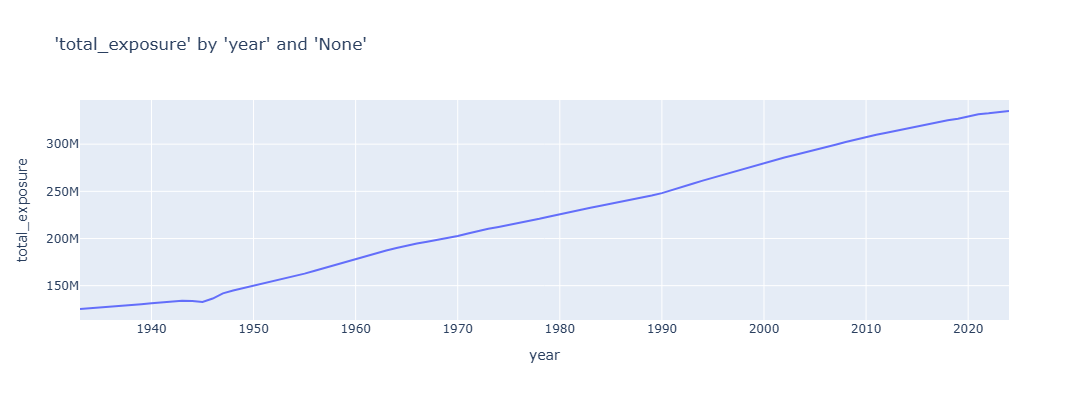

In [8]:
charters.chart(
    df=hmd_df,
    x_axis="year",
    y_axis="total_exposure",
    display=True,
)

 2025-07-08 09:37:28 | morai.experience.charters | INFO     | Calculating ratio using [total_death] and [total_exposure] 


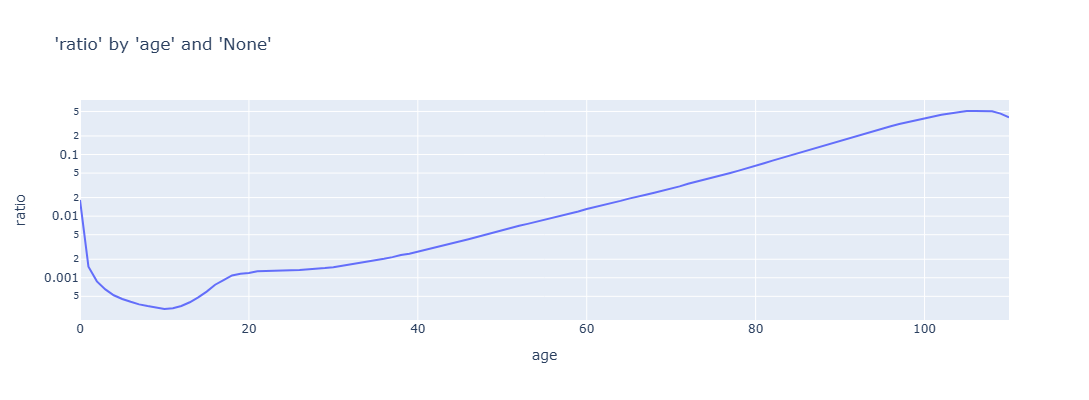

In [16]:
charters.chart(
    df=hmd_df,
    x_axis="age",
    y_axis="ratio",
    numerator="total_death",
    denominator="total_exposure",
    y_log=True,
    display=True,
)

### Refresh Data

In [ ]:
hmd_df = hmd.get_hmd_exposure_and_deaths(email="", password="")

In [24]:
sql.export_to_sql(
    df=hmd_df,
    db_filepath=db_filepath,
    table_name="hmd",
    if_exists="replace",
)

 2025-10-22 20:18:15 | morai.utils.sql | INFO     | replace data to SQLite database: `files/integrations/hmd/hmd2.sql` and table: `hmd` 


In [26]:
hmd_df.shape

(100, 12)

## Reload

In [40]:
import importlib

importlib.reload(hmd)

<module 'morai.integrations.hmd' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\integrations\\hmd.py'>